In [1]:
import pandas as pd

df = pd.concat([
    pd.read_csv('OpenData_IPDCNational01_2023.csv'),
    pd.read_csv('OpenData_IPDCNational01_2024-1.csv'),
    pd.read_csv('OpenData_IPDCNational01_2026.csv'),
    pd.read_csv('OpenData_IPDCNational01_2025.csv'),
], ignore_index=True)

df.columns = df.columns.str.strip()

print("Rows:", len(df))
print("Hospitals:", df['HospitalName'].nunique())
print(df.head())

Rows: 2630
Hospitals: 46
  ArchiveDate Adult_Child                                  HospitalName  \
0  26/01/2023       Adult                       Bantry General Hospital   
1  26/01/2023       Adult                             Beaumont Hospital   
2  26/01/2023       Adult                        Cavan General Hospital   
3  26/01/2023       Adult              Connolly Hospital Blanchardstown   
4  26/01/2023       Adult  Coombe Women and Infants University Hospital   

  0-6 Months 6-12 Months 12-18 Months 18 Months +  Total  
0         59          41           21           5    126  
1      3,998       1,515          228          29  5,771  
2        406          11            0           0    417  
3      1,068         133            8           0  1,209  
4        138          41            8           2    189  


Why i didn't used 2022 Data set ?
On that time we had a pandemic situation was there beacude people were affected by COvid 19



In [2]:
date_col = 'ArchiveDate'
hospital_col = 'HospitalName'
adult_col = 'Adult_Child'
df[date_col] = pd.to_datetime(df[date_col], format='mixed', dayfirst=True, errors='coerce')

w_0_6 = '0-6 Months'
w_6_12 = '6-12 Months'
w_12_18 = '12-18 Months'
w_18_plus = '18 Months +'

cols = [w_0_6, w_6_12, w_12_18, w_18_plus]

for col in cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')

df[date_col] = pd.to_datetime(df[date_col], dayfirst=True)

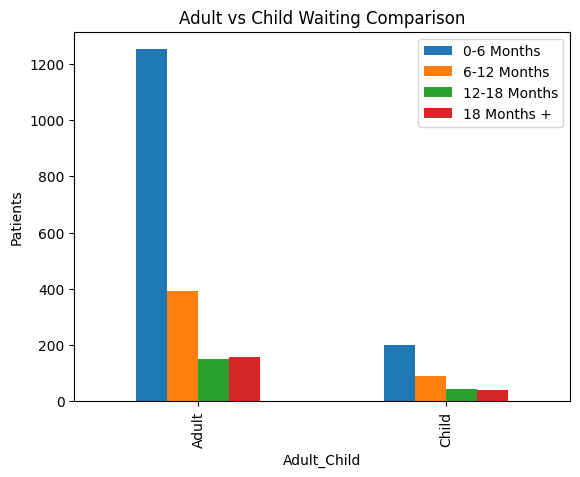

In [3]:
import matplotlib.pyplot as plt

group_data = df.groupby(adult_col)[cols].mean()
group_data.plot(kind='bar')
plt.title("Adult vs Child Waiting Comparison")
plt.ylabel("Patients")
plt.show()

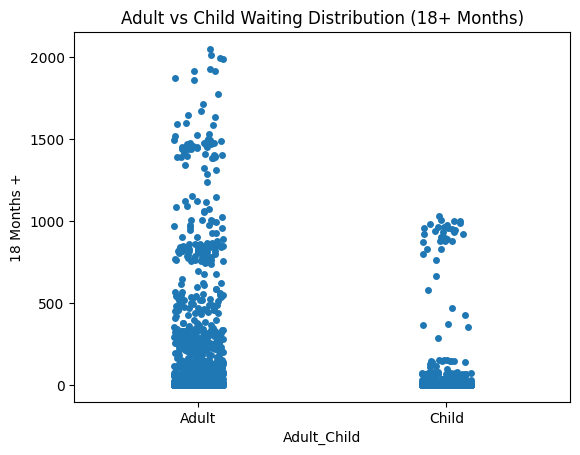

In [6]:
import seaborn as sns
sns.stripplot(x=adult_col, y=w_18_plus, data=df, jitter=True)

plt.title("Adult vs Child Waiting Distribution (18+ Months)")
plt.show()

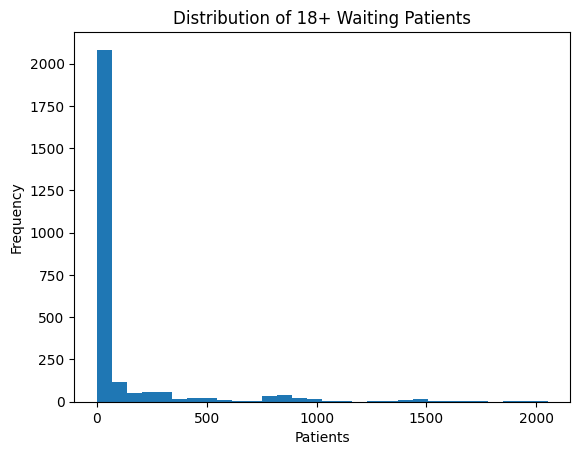

In [7]:
plt.hist(df[w_18_plus], bins=30)

plt.title("Distribution of 18+ Waiting Patients")
plt.xlabel("Patients")
plt.ylabel("Frequency")
plt.show()

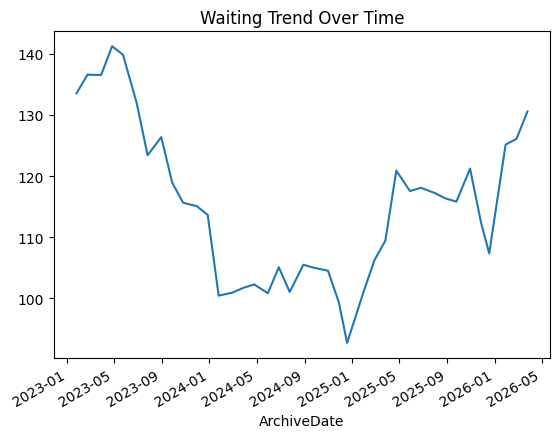

In [8]:
trend = df.groupby(date_col)[w_18_plus].mean()
trend.plot()
plt.title("Waiting Trend Over Time")
plt.show()

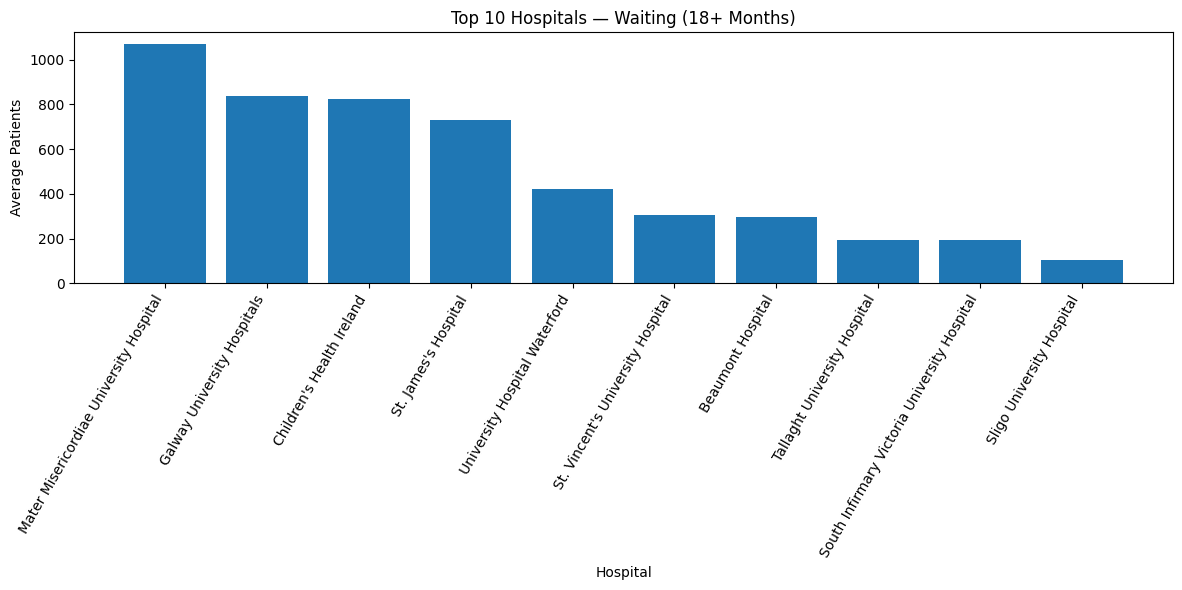

In [9]:

top_hospitals = df.groupby(hospital_col)[w_18_plus].mean().sort_values(ascending=False).head(10)

labels = top_hospitals.index.str.strip()

plt.figure(figsize=(12,6))

bars = plt.bar(labels, top_hospitals.values)

plt.title("Top 10 Hospitals — Waiting (18+ Months)")
plt.xlabel("Hospital")
plt.ylabel("Average Patients")

plt.xticks(rotation=60, ha='right')  # rotate for readability
plt.tight_layout()

plt.show()

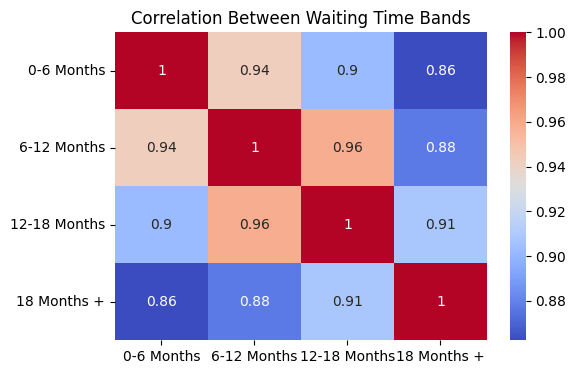

In [10]:
corr = df[[w_0_6, w_6_12, w_12_18, w_18_plus]].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Between Waiting Time Bands")
plt.show()

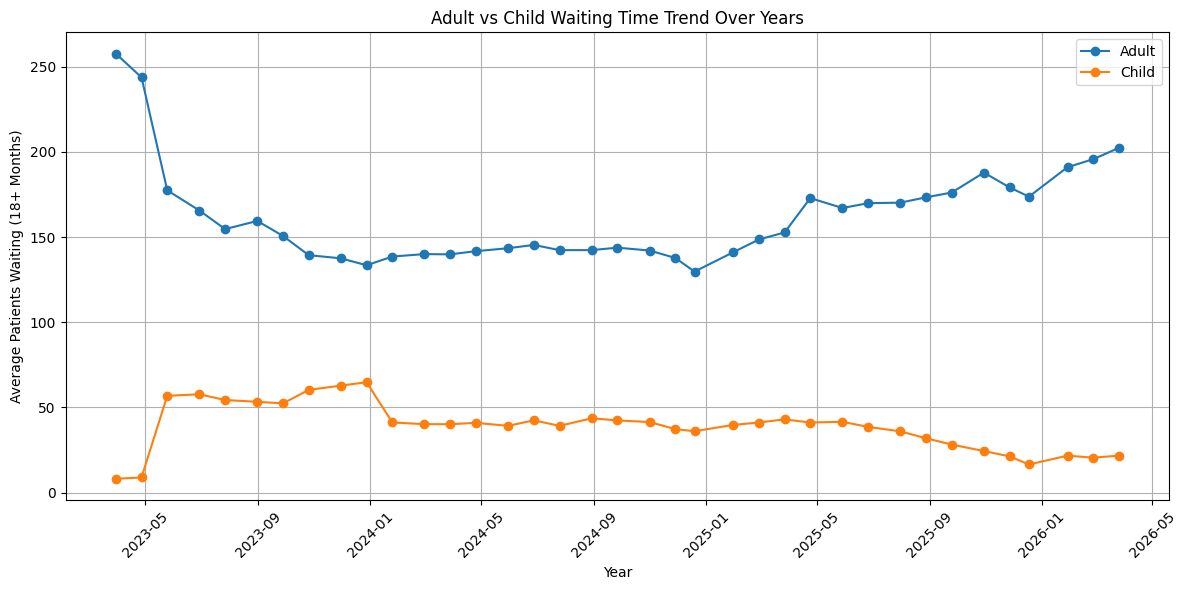

In [19]:
df[date_col] = pd.to_datetime(df[date_col], format='mixed', dayfirst=True)


adult_data = df[df[adult_col] == 'Adult']
adult_trend = adult_data.groupby(date_col)[w_18_plus].mean()


child_data = df[df[adult_col] == 'Child']
child_trend = child_data.groupby(date_col)[w_18_plus].mean()

plt.figure(figsize=(12,6))

plt.plot(adult_trend.index,
         adult_trend.values,
         label='Adult',
         marker='o')

plt.plot(child_trend.index,
         child_trend.values,
         label='Child',
         marker='o')

# Labels
plt.title("Adult vs Child Waiting Time Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Average Patients Waiting (18+ Months)")

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

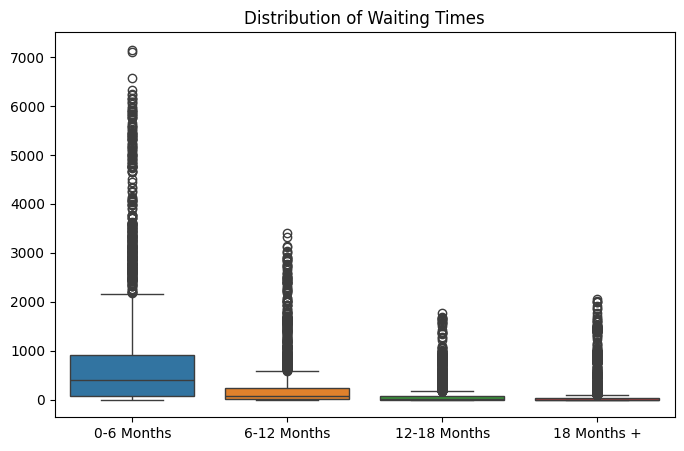

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[cols])

plt.title("Distribution of Waiting Times")
plt.show()

In [21]:
df = df.sort_values([hospital_col, date_col])

df['lag_18'] = df.groupby(hospital_col)[w_18_plus].shift(1)
df['roll_18'] = df.groupby(hospital_col)[w_18_plus].transform(lambda x: x.rolling(3).mean())

df = df.dropna()

df['Breach'] = (df[w_18_plus] > 500).astype(int)

In [22]:
df = df.sort_values([hospital_col, date_col])

df['lag_18'] = df.groupby(hospital_col)[w_18_plus].shift(1)
df['roll_18'] = df.groupby(hospital_col)[w_18_plus].transform(lambda x: x.rolling(3).mean())

df = df.dropna()

df['Breach'] = (df[w_18_plus] > 500).astype(int)

In [23]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, f1_score
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

X = df[['lag_18', 'roll_18']]
y = df['Breach']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

models = {
    "Logistic": LogisticRegression(),
    "RandomForest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [24]:
for name, model in models.items():
    acc, prec, f1 = [], [], []

    for train_idx, test_idx in cv.split(X_scaled, y):
        X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc.append(accuracy_score(y_test, y_pred))
        prec.append(precision_score(y_test, y_pred))
        f1.append(f1_score(y_test, y_pred))

    print(f"\n{name}")
    print(f"Accuracy : {np.mean(acc):.4f}")
    print(f"Precision: {np.mean(prec):.4f}")
    print(f"F1 Score : {np.mean(f1):.4f}")


Logistic
Accuracy : 0.9956
Precision: 0.9882
F1 Score : 0.9713

RandomForest
Accuracy : 0.9951
Precision: 0.9717
F1 Score : 0.9689

XGBoost
Accuracy : 0.9960
Precision: 0.9779
F1 Score : 0.9746


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:20:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:20:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:20:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:20:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

In [25]:
pred = model.predict(X_scaled)

from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y, pred))

print("\nSTATISTICS")
print("Mean waiting:", df[w_18_plus].mean())
print("RMSE:", rmse)
print("Std Dev:", df[w_18_plus].std())


STATISTICS
Mean waiting: 111.70910698496905
RMSE: 0.03641785203646149
Std Dev: 288.7286124943033


In [26]:
from scipy.stats import ttest_ind

adult = df[df[adult_col]=='Adult'][w_18_plus]
child = df[df[adult_col]=='Child'][w_18_plus]

t_stat, p_val = ttest_ind(adult, child)

print("\nHYPOTHESIS TEST")
print("p-value:", p_val)


HYPOTHESIS TEST
p-value: 2.1603419531929128e-24


In [27]:
hospital_summary = df.groupby(hospital_col)[w_18_plus].mean().sort_values(ascending=False)

print("\nTOP 5 HOSPITALS — HSE WLAP 2025 RECOMMENDATIONS")

for i, (hosp, val) in enumerate(hospital_summary.head(5).items()):
    print("\n" + "="*60)
    print(f"{i+1}. {hosp}")
    print(f"Avg patients waiting 18+ months: {int(val)}")

    print("\nHSE Waiting List Action Plan 2025 RECOMMENDATIONS")
    if val > 1000:
        print("\nRisk Level: CRITICAL")

        print("\nRecommended Actions (HSE / NTPF):")
        print("1. Refer patients to NTPF-funded private hospitals (outsourcing)")
        print("2. Increase hospital capacity (evening & weekend operations)")
        print("3. Allocate cases to Surgical Hubs (Dublin / Cork / Galway / Limerick)")
        print("4. Prioritise patients waiting longest (>24 months)")
        print("5. Perform administrative validation to clean waiting list")
        print("6. Escalate to Regional Health Authority")

    elif val > 500:
        print("\nRisk Level: HIGH")

        print("\nRecommended Actions:")
        print("1. Add extra theatre sessions (evenings/weekends)")
        print("2. Start Patient Initiated Review (reduce unnecessary follow-ups)")
        print("3. Improve clinical prioritisation (urgent cases first)")
        print("4. Monitor waiting list monthly at regional level")
        print("5. Use partial outsourcing if capacity is limited")

    elif val > 100:
        print("\nRisk Level: MEDIUM")

        print("\nRecommended Actions:")
        print("1. Improve scheduling efficiency and reduce delays")
        print("2. Shift suitable patients to community care")
        print("3. Use central referral system to balance workload")
        print("4. Regular quarterly performance review")

    else:
        print("\nRisk Level: SAFE")

        print("\nRecommended Actions:")
        print("1. Maintain current performance")
        print("2. Monitor waiting list trends monthly")
        print("3. Share best practices with higher-risk hospitals")


TOP 5 HOSPITALS — HSE WLAP 2025 RECOMMENDATIONS

1. Mater Misericordiae University Hospital
Avg patients waiting 18+ months: 1090

HSE Waiting List Action Plan 2025 RECOMMENDATIONS

Risk Level: CRITICAL

Recommended Actions (HSE / NTPF):
1. Refer patients to NTPF-funded private hospitals (outsourcing)
2. Increase hospital capacity (evening & weekend operations)
3. Allocate cases to Surgical Hubs (Dublin / Cork / Galway / Limerick)
4. Prioritise patients waiting longest (>24 months)
5. Perform administrative validation to clean waiting list
6. Escalate to Regional Health Authority

2. Galway University Hospitals
Avg patients waiting 18+ months: 815

HSE Waiting List Action Plan 2025 RECOMMENDATIONS

Risk Level: HIGH

Recommended Actions:
1. Add extra theatre sessions (evenings/weekends)
2. Start Patient Initiated Review (reduce unnecessary follow-ups)
3. Improve clinical prioritisation (urgent cases first)
4. Monitor waiting list monthly at regional level
5. Use partial outsourcing if 

These plans and reccomendations are taken from the Waiting List Action Plan 2025 (Official Government Document) - https://www.gov.ie/en/department-of-health/publications/waiting-list-action-plan-2025.com  https://assets.gov.ie/static/documents/waiting-list-action-wlap-2025.pdf